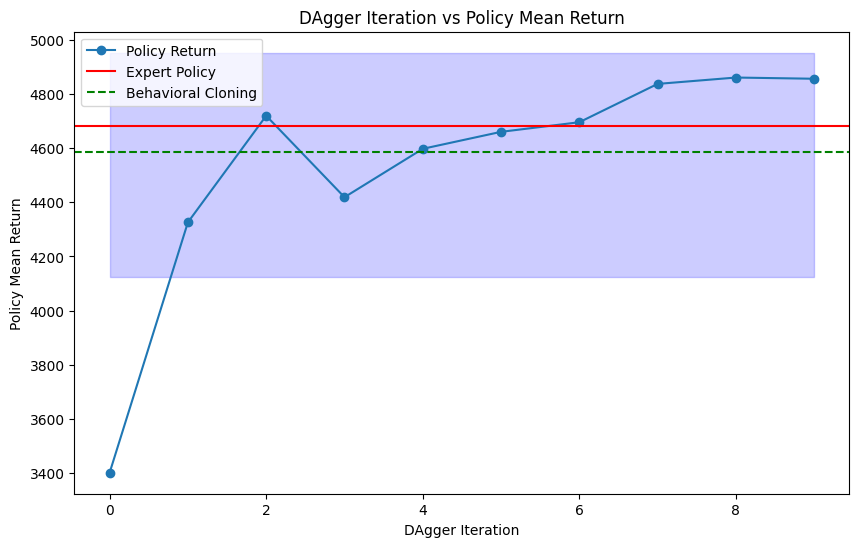

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Your data: [timestamp, DAgger iteration, policy return]
data = [
    [1700372842.0037663, 0, 3401.850830078125],
    [1700372844.372758, 1, 4326.2705078125],
    [1700372846.4225714, 2, 4719.56298828125],
    [1700372850.6334846, 3, 4418.8583984375],
    [1700372854.1809072, 4, 4597.5107421875],
    [1700372857.8448524, 5, 4660.1611328125],
    [1700372861.465189, 6, 4695.6396484375],
    [1700372865.2428732, 7, 4837.0869140625],
    [1700372869.0991874, 8, 4860.59765625],
    [1700372872.9648068, 9, 4856.111328125]
]

# Extracting DAgger iterations and policy returns
iterations = [point[1] for point in data]
returns = [point[2] for point in data]

# Calculate mean and standard deviation
mean_return = np.mean(returns)
std_deviation = np.std(returns)

# Expert policy baseline and behavioral cloning point
expert_policy = 4682
behavioral_cloning = 4585.5176

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(iterations, returns, marker='o', label='Policy Return')
plt.axhline(y=expert_policy, color='r', linestyle='-', label='Expert Policy')
plt.axhline(y=behavioral_cloning, color='g', linestyle='--', label='Behavioral Cloning')

# Adding standard deviation area
plt.fill_between(iterations, mean_return - std_deviation, mean_return + std_deviation, color='blue', alpha=0.2)

# Customizing the plot
plt.xlabel('DAgger Iteration')
plt.ylabel('Policy Mean Return')
plt.title('DAgger Iteration vs Policy Mean Return')
plt.legend()

# Show plot
plt.show()


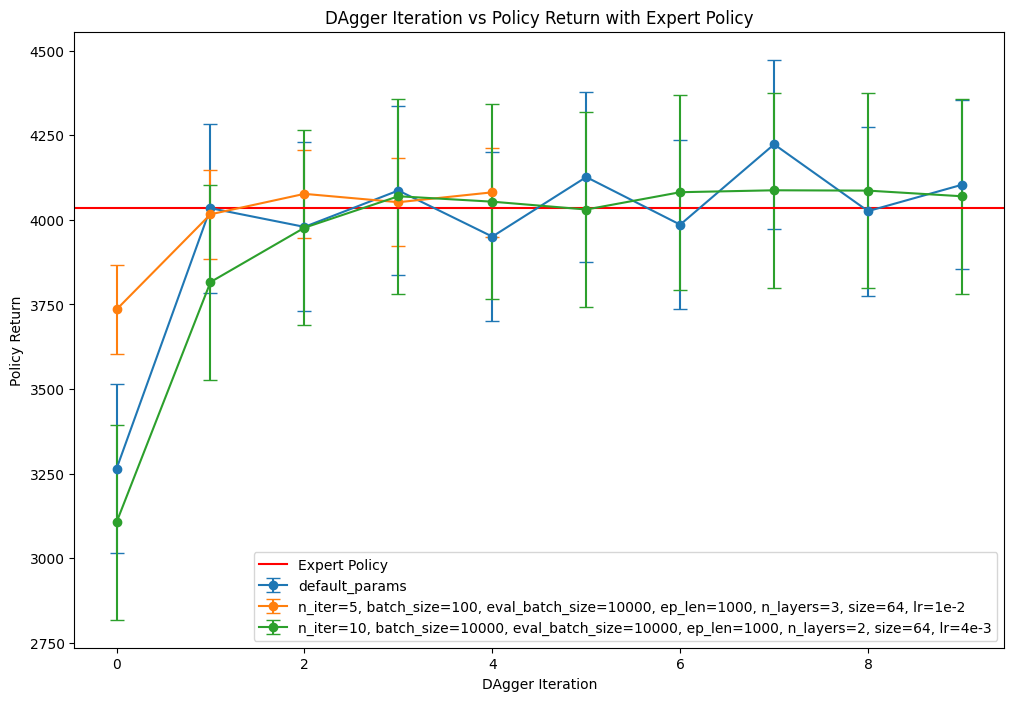

In [4]:
import json
import matplotlib.pyplot as plt

# Function to read data from a JSON file
def read_json_data(filename):
    with open(filename, 'r') as file:
        return json.load(file)

# File names with their corresponding detailed labels
files = [
    ('/home/jimchen/Downloads/run3_..json', 'default_params'),
    ('/home/jimchen/Downloads/run1_..json', 'n_iter=5, batch_size=100, eval_batch_size=10000, ep_len=1000, n_layers=3, size=64, lr=1e-2'),
    ('/home/jimchen/Downloads/run2_..json', 'n_iter=10, batch_size=10000, eval_batch_size=10000, ep_len=1000, n_layers=2, size=64, lr=4e-3')
]
expert_policy_performance = 4035

# Initialize plot
plt.figure(figsize=(12, 8))
# Loop through each file and plot the data
for filename, label in files:
    data = read_json_data(filename)
    iterations = [point[1] for point in data]  # DAgger iterations
    returns = [point[2] for point in data]    # Policy returns
    mean_return = np.mean(returns)
    std_deviation = np.std(returns)

    plt.errorbar(iterations, returns, yerr=std_deviation, fmt='-o', capsize=5, label=label)

# Add horizontal line for expert policy performance
plt.axhline(y=expert_policy_performance, color='r', linestyle='-', label='Expert Policy')

# Customizing the plot
plt.xlabel('DAgger Iteration')
plt.ylabel('Policy Return')
plt.title('DAgger Iteration vs Policy Return with Expert Policy')
plt.legend()

# Show plot
plt.show()


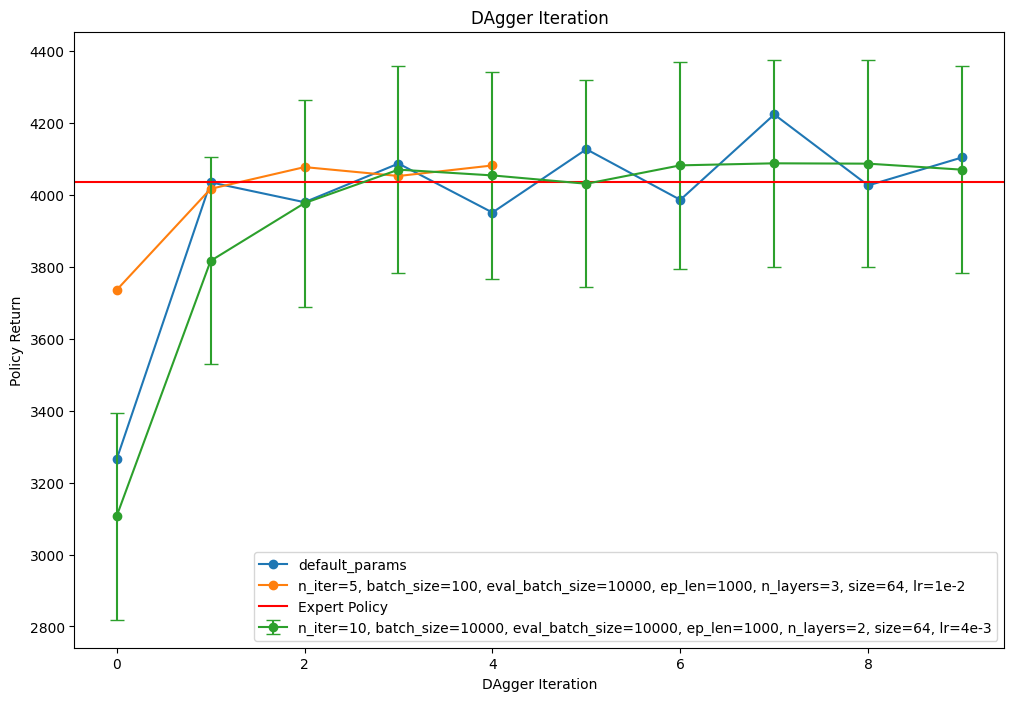

In [6]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Function to read data from a JSON file
def read_json_data(filename):
    with open(filename, 'r') as file:
        return json.load(file)

# File names with their corresponding detailed labels
files = [
    ('/home/jimchen/Downloads/run3_..json', 'default_params', False),
    ('/home/jimchen/Downloads/run1_..json', 'n_iter=5, batch_size=100, eval_batch_size=10000, ep_len=1000, n_layers=3, size=64, lr=1e-2', False),
    ('/home/jimchen/Downloads/run2_..json', 'n_iter=10, batch_size=10000, eval_batch_size=10000, ep_len=1000, n_layers=2, size=64, lr=4e-3', True)
]
expert_policy_performance = 4035

# Initialize plot
plt.figure(figsize=(12, 8))

# Loop through each file and plot the data
for filename, label, show_error in files:
    data = read_json_data(filename)
    iterations = [point[1] for point in data]  # DAgger iterations
    returns = [point[2] for point in data]    # Policy returns
    
    # Check if this run should have error bars
    if show_error:
        # Plot with error bars
        std_deviation = np.std(returns)
        plt.errorbar(iterations, returns, yerr=std_deviation, fmt='-o', capsize=5, label=label)
    else:
        # Plot without error bars
        plt.plot(iterations, returns, '-o', label=label)

# Add horizontal line for expert policy performance
plt.axhline(y=expert_policy_performance, color='r', linestyle='-', label='Expert Policy')

# Customizing the plot
plt.xlabel('DAgger Iteration')
plt.ylabel('Policy Return')
plt.title('DAgger Iteration')
plt.legend()

# Show plot
plt.show()
